# NEOFC - Prepare physio data for HCP-Young Adult

In [3]:
from pathlib import Path 
import pandas as pd 
import numpy as np 
import shutil
from tqdm.auto import tqdm
from tqdm.auto import tqdm
from joblib import Parallel, delayed
import matplotlib.pyplot as plt

import neurokit2 as nk
from kneed import KneeLocator
from nispace.io import write_json, read_json

# working directory
wd = Path.cwd() 
print(wd)

/Users/llotter/projects/mapfc


## Function for physio processing

In [4]:
def process_signals(arr_pulse, arr_resp, fq=400, report=True):
    
    # PPG
    try:
        ppg_signals, ppg_info = nk.ppg_process(
            arr_pulse, 
            sampling_rate=fq,
            method="elgendi",
            report="text" if report else None
        )
    except Exception as e:
        print("Error:", e)
        return 
    
    # RSP
    try:
        rsp_signals, rsp_info = nk.rsp_process(
            arr_resp,
            sampling_rate=fq,
            method="BioSPPy",
            report="text" if report else None
        )
    except Exception as e:
        print("Error:", e)
        return 
    
    # concat
    bio_signals = pd.concat([ppg_signals, rsp_signals], axis=1)
    
    # time indices
    bio_signals["TIME_sampling"] = np.arange(len(arr_pulse))
    bio_signals["TIME_seconds"] = np.arange(len(arr_pulse)) / fq
    
    # PPG peak amplitude
    # https://github.com/tsb46/fmri_arousal/blob/main/utils/physio_utils.py#L98
    ppg_peaks_loc = np.where(bio_signals['PPG_Peaks'])[0]
    ppg_peaks_amp = np.abs(bio_signals['PPG_Clean'].iloc[ppg_peaks_loc])
    bio_signals["PPG_Peak_Amp"] = ppg_peaks_amp
    
    # HRV for the whole run
    hrv = nk.hrv_time(bio_signals, sampling_rate=fq, robust=True).loc[0, "HRV_RMSSD"]
    bio_signals["PPG_HRV"] = hrv
    
    # set indices
    bio_signals = bio_signals.set_index(["TIME_sampling"])
    
    # sort columns
    cols_ppg = [c for c in bio_signals.columns if c.startswith("PPG")]
    cols_rsp = [c for c in bio_signals.columns if c.startswith("RSP")]
    bio_signals = bio_signals[["TIME_seconds"] + cols_ppg + cols_rsp]
    
    # return
    return bio_signals    

## Load data

### Define subjects

In [5]:
# physio data dir
hcp_physio_dir = wd / "data_source" / "pheno" / "hcp_ya" / "physio"

# subjects for which there is physio data
subs = [fp.name.split("_")[0].split("-")[1] for fp in hcp_physio_dir.glob("sub-*_physio.tsv.gz")]
# intersection with test sample
subs = np.intersect1d(subs, np.loadtxt(wd / "data_source" / "pheno" / "hcp_ya" / "hcp_ya_subjects.txt", dtype=str).tolist())


### Actually load data

In [ ]:
# load physio data
hcp_ya_physio = {}
for sub in tqdm(subs):
    df = pd.read_table(hcp_physio_dir / f"sub-{sub}_physio.tsv.gz", index_col=0, header=None)
    for ses in ["REST1_LR", "REST1_RL", "REST2_LR", "REST2_RL"]:
        hcp_ya_physio[sub, ses] = df[df.index.str.contains(ses)].values[:, :]


## Process data

In [5]:
fq = 400

hcp_physio_proc_dir = wd / "data_deriv" / "pheno" / "hcp_ya" / "physio"
shutil.rmtree(hcp_physio_proc_dir, ignore_errors=True)
hcp_physio_proc_dir.mkdir(parents=True, exist_ok=True)

def process_fun(sub, ses, data):
    
    # get data
    arr_resp = data[:, 1]
    arr_pulse = data[:, 2]
    
    # run processing
    bio_signals = process_signals(arr_pulse, arr_resp, fq, report=False)
    if bio_signals is None:
        return
    bio_signals = bio_signals.astype(np.float32)
    
    # save
    fp = wd / "data_deriv" / "pheno" / "hcp_ya" / "physio" / f"sub-{sub}_ses-{ses.split('_')[0]}_dir-{ses.split('_')[1]}_physio_proc.csv.gz"
    bio_signals.to_csv(fp)
    
    
_ = Parallel(n_jobs=-1)(
    delayed(process_fun)(sub, ses, data) 
    for (sub, ses), data 
    in tqdm(hcp_ya_physio.items())
)    

  0%|          | 0/420 [00:00<?, ?it/s]

/Applications/miniforge3/envs/mapfc/lib/python3.10/site-packages/neurokit2/signal/signal_period.py:84: NeuroKitWarning: Too few peaks detected to compute the rate. Returning empty vector.
  warn(
/Applications/miniforge3/envs/mapfc/lib/python3.10/site-packages/neurokit2/signal/signal_period.py:84: NeuroKitWarning: Too few peaks detected to compute the rate. Returning empty vector.
  warn(


Error: cannot convert float NaN to integer
Error: cannot convert float NaN to integer


/Applications/miniforge3/envs/mapfc/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


## Prepare relevant data for analysis

  0%|          | 0/420 [00:00<?, ?it/s]

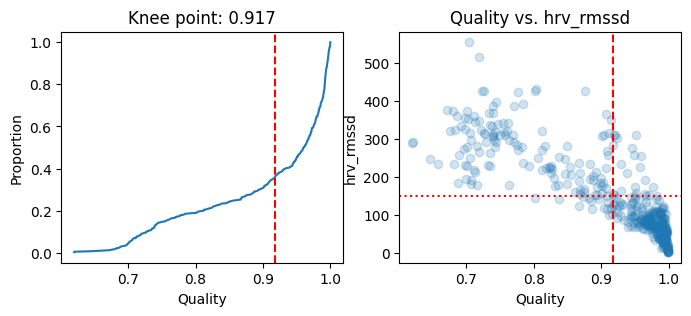

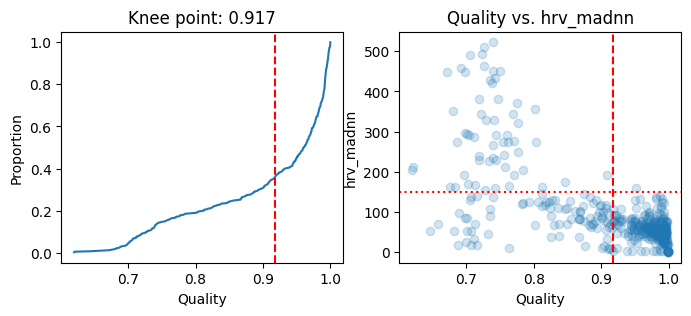

PosixPath('/Users/llotter/projects/mapfc/data_deriv/pheno/hcp_ya/physio/hcp_ya_physio_thresholds.json')

In [11]:
# prep dataframe
df_physio = pd.DataFrame(
    index=pd.MultiIndex.from_product(
        [subs, ["REST1", "REST2"], ["LR", "RL"]], 
        names=["sub", "ses", "dir"]
    ),
    columns=["hrv_rmssd", "hrv_madnn", "quality_mean"]
)

# iterate subjects
for sub, ses, d in tqdm(df_physio.index):
    fp = wd / "data_deriv" / "pheno" / "hcp_ya" / "physio" / f"sub-{sub}_ses-{ses}_dir-{d}_physio_proc.csv.gz"
    if not fp.exists():
        continue
    if sub == "163129" and ses == "REST2" and d == "LR":
        continue
    elif sub == "201111" and ses == "REST1" and d == "LR":
        continue
    bio_signals = pd.read_csv(fp).set_index("TIME_seconds")

    # whole session
    hrv = nk.hrv_time(bio_signals, sampling_rate=400, robust=True)
    df_physio.loc[(sub, ses, d), ["hrv_rmssd", "hrv_madnn"]] = hrv.loc[0, ["HRV_RMSSD", "HRV_MadNN"]].values
    df_physio.loc[(sub, ses, d), "quality_mean"] = bio_signals["PPG_Quality"].mean()
    df_physio.loc[(sub, ses, d), "quality_min"] = bio_signals["PPG_Quality"].min()
    df_physio.loc[(sub, ses, d), "quality_median"] = bio_signals["PPG_Quality"].median()
    df_physio.loc[(sub, ses, d), "quality_pct25"] = bio_signals["PPG_Quality"].quantile(0.25)

# collect data
df_physio = df_physio.astype(float)
df_physio = df_physio.dropna(how="all")
#display(df_physio.head())

# define quality threshold data-driven
thresholds = {}
for var, upper_bound in [("hrv_rmssd", 150), ("hrv_madnn", 150)]:
    
    # get data and quality index
    hrv = df_physio[var]
    q = df_physio["quality_mean"]
    
    # prep "knee plot" and find knee point based on curvature
    q_sorted = q.sort_values()
    prop = np.arange(1, len(q)+1) / len(q)
    knee = KneeLocator(q_sorted, prop, curve="convex", direction="increasing", online=True).knee
    
    # mark thresholds in data
    df_physio[f"{var}_qc"] = (df_physio["quality_mean"] >= knee) & (df_physio[var] <= upper_bound)
    
    # save thresholds
    thresholds[var] = {
        "knee": knee,
        "upper_bound": upper_bound
    }
    
    # plot
    fig, axes = plt.subplots(1, 2, figsize=(8, 3))
    axes[0].plot(q_sorted, prop)
    axes[0].axvline(knee, color="red", linestyle="--")
    axes[0].set_xlabel("Quality")
    axes[0].set_ylabel("Proportion")
    axes[0].set_title(f"Knee point: {knee:.03f}")
    axes[1].scatter(q, hrv, alpha=0.2)
    axes[1].axhline(upper_bound, color="red", linestyle=":")
    axes[1].axvline(knee, color="red", linestyle="--")
    axes[1].set_xlabel("Quality")
    axes[1].set_ylabel(var)
    axes[1].set_title(f"Quality vs. {var}")
    plt.show()

# save
df_physio.to_csv(wd / "data_deriv" / "pheno" / "hcp_ya" / "physio" / "hcp_ya_physio_proc.csv")
write_json(thresholds, wd / "data_deriv" / "pheno" / "hcp_ya" / "physio" / "hcp_ya_physio_thresholds.json")

## Plot

### Plot physio data overview

In [12]:
def plot_physio(bio_signals, plotting_window_seconds=60 * 2, fq=400):
        
    # plot settings
    window = plotting_window_seconds * fq

    # plot
    fig, axes = plt.subplots(9, 1, figsize=(20, 10), sharex=True)

    # row 1: raw ppg signal
    axes[0].set_title("PPG: Raw Signal")
    axes[0].plot(bio_signals["PPG_Raw"].iloc[:window], color="red")

    # row 2: clean ppg signal
    axes[1].set_title("PPG: Clean Signal")
    axes[1].plot(bio_signals["PPG_Clean"].iloc[:window], color="green")
    for i in bio_signals.iloc[:window].query("PPG_Peaks==1")["PPG_Peaks"].index:
        axes[1].axvline(x=i, color="black", alpha=0.7)

    # row 3: ppg peak amplitude
    axes[2].set_title("PPG: Peak Amplitude")
    axes[2].plot(bio_signals["PPG_Peak_Amp"].iloc[:window].dropna(), color="blue")

    # row 4: heart rate
    axes[3].set_title("PPG: Heart Rate")
    axes[3].plot(bio_signals["PPG_Rate"].iloc[:window], color="orange")

    # # row 5: hrv example
    axes[4].set_title("PPG: HRV (RMSSD)")
    axes[4].plot(bio_signals["PPG_HRV"].iloc[:window].dropna(), color="purple")

    # row 6: rsp raw signal
    axes[5].set_title("RSP: Raw Signal")
    axes[5].plot(bio_signals["RSP_Raw"].iloc[:window], color="orange")

    # row 7: rsp clean signal
    axes[6].set_title("RSP: Clean Signal")
    axes[6].plot(bio_signals["RSP_Clean"].iloc[:window], color="orange")
    for i in bio_signals.iloc[:window].query("RSP_Peaks==1")["RSP_Peaks"].index:
        axes[6].axvline(x=i, color="black", alpha=0.7)

    # row 8: respiratory rate
    axes[7].set_title("RSP: Respiratory Rate")
    axes[7].plot(bio_signals["RSP_Rate"].iloc[:window], color="orange")

    # row 9: rvt
    axes[8].set_title("RSP: RVT")
    axes[8].plot(bio_signals["RSP_RVT"].iloc[:window], color="orange")

    xticks = np.arange(0, plotting_window_seconds + 10, 10)
    axes[4].set_xticks(xticks * fq)
    axes[4].set_xticklabels(xticks)
    
    return fig, axes

In [13]:
from matplotlib.backends.backend_pdf import PdfPages

with PdfPages(wd / "data_deriv" / "pheno" / "hcp_ya" / "physio" / "hcp_ya_physio.pdf") as pdf:
    for sub, ses, d in tqdm(df_physio.index[:10]):
        fp = wd / "data_deriv" / "pheno" / "hcp_ya" / "physio" / f"sub-{sub}_ses-{ses}_dir-{d}_physio_proc.csv.gz"
        bio_signals = pd.read_csv(fp)
        fig, axes = plot_physio(bio_signals)
        axes[0].annotate(f"{sub} | {ses} | {d}: QC={df_physio.loc[(sub, ses, d), 'hrv_rmssd_qc']}", 
                         xy=(0.5, 1.8), xycoords="axes fraction", ha="center", va="center",
                         fontsize=15, fontweight="bold")
        fig.tight_layout()
        pdf.savefig()
        plt.close()
                    

  0%|          | 0/10 [00:00<?, ?it/s]

### Plot QC checks

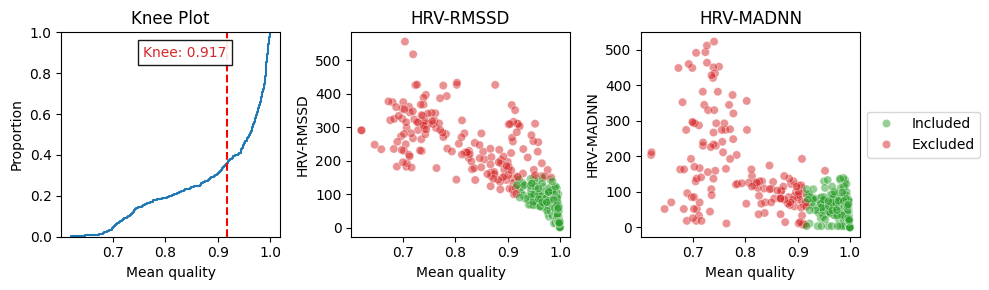

In [14]:
import seaborn as sn

thresholds = read_json(wd / "data_deriv" / "pheno" / "hcp_ya" / "physio" / "hcp_ya_physio_thresholds.json")
knee = thresholds["hrv_rmssd"]["knee"]

fig, axes = plt.subplots(1, 3, figsize=(10,3))

# knee
ax = axes[0]
sn.ecdfplot(
    df_physio["quality_mean"],
    ax=ax
)
ax.axvline(knee, color="red", linestyle="--")
ax.annotate(f"Knee: {knee:.03f}", xy=(knee, 0.9), color="tab:red", ha="right", va="center",
            bbox=dict(facecolor="white", alpha=0.9))
ax.set_xlabel("Mean quality")
ax.set_title("Knee Plot")

for c, var in enumerate(["hrv_rmssd", "hrv_madnn"], start=1):
    ax = axes[c]
    sn.scatterplot(
        y=df_physio[var],
        x=df_physio["quality_mean"],
        hue=df_physio[f"{var}_qc"].map({True: "Included", False: "Excluded"}),
        alpha=0.5,
        palette={"Included": "tab:green", "Excluded": "tab:red"},
        ax=ax,
    )
    ax.set_xlabel("Mean quality")
    ax.set_ylabel(var.replace("_", "-").upper())
    ax.set_title(var.replace("_", "-").upper())
    if ax.get_subplotspec().is_last_col():
        ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
    else:
        ax.legend().set_visible(False)

fig.tight_layout()
fig.savefig(wd / "plots" / "physio" / "hrv_qc.pdf", bbox_inches="tight")
plt.show()